# Creation of Abe-Suzuki Earthquake Network

## Creating two types of networks with different cell size $5\times5\times5 km^3$ and $10\times10\times10 km^3$

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
from pyproj import Transformer
import time

# ==========================================
# 1. Spatial Discretization Function
# ==========================================
def discretize_space_3d(df, cell_size_km):
    """
    Converts geographic coordinates to a 3D Cartesian grid and assigns each 
    earthquake to a specific cubic cell.
    """
    print(f"Projecting coordinates and creating {cell_size_km}x{cell_size_km}x{cell_size_km} km grid...")
    
    # 1. Convert Lat/Lon (EPSG:4326) to a metric system (UTM Zone 32N - EPSG:32632 for Italy)
    # This ensures our km measurements are accurate on the Earth's surface
    transformer = Transformer.from_crs("epsg:4326", "epsg:32632", always_xy=True)
    
    # Transform coordinates
    x_meters, y_meters = transformer.transform(df['longitude'].values, df['latitude'].values)
    
    # Convert meters to kilometers
    df['x_km'] = x_meters / 1000.0
    df['y_km'] = y_meters / 1000.0
    df['z_km'] = df['depth/km'].values # Z is already in km
    
    # 2. Shift coordinates so the minimum value is exactly 0 (creating a local bounding box)
    x_shifted = df['x_km'] - df['x_km'].min()
    y_shifted = df['y_km'] - df['y_km'].min()
    z_shifted = df['z_km'] - df['z_km'].min()
    
    # 3. Calculate cell indices (i, j, k)
    # Using np.floor to bin continuous coordinates into discrete cell integers
    df['cell_x'] = np.floor(x_shifted / cell_size_km).astype(int)
    df['cell_y'] = np.floor(y_shifted / cell_size_km).astype(int)
    df['cell_z'] = np.floor(z_shifted / cell_size_km).astype(int)
    
    # 4. Create a unique string ID for each cell (e.g., "12_45_2")
    df['cell_id'] = df['cell_x'].astype(str) + "_" + \
                    df['cell_y'].astype(str) + "_" + \
                    df['cell_z'].astype(str)
    
    return df

# ==========================================
# 2. Abe-Suzuki Network Builder
# ==========================================
def build_abe_suzuki_network(df, cell_size_km):
    """
    Builds the Abe-Suzuki directed network where nodes are 3D spatial cells
    and edges are consecutive seismic events.
    """
    start_time = time.time()
    
    # Step 1: Assign cells to earthquakes
    df_grid = discretize_space_3d(df.copy(), cell_size_km)
    
    # Extract the sequence of cell IDs chronologically
    cell_sequence = df_grid['cell_id'].tolist()
    
    # Initialize Directed Graph
    G = nx.DiGraph()
    
    print("Building network edges from consecutive events...")
    
    # Step 2: Iterate through the sequence (event N connected to event N+1)
    for i in range(len(cell_sequence) - 1):
        source_cell = cell_sequence[i]
        target_cell = cell_sequence[i + 1]
        
        # If the edge already exists, just increase its weight (transition frequency)
        if G.has_edge(source_cell, target_cell):
            G[source_cell][target_cell]['weight'] += 1
        else:
            # Create a new edge with weight 1
            G.add_edge(source_cell, target_cell, weight=1)
            
    # Step 3: Add basic attributes to nodes (optional, but useful for mapping later)
    # Let's calculate the geographic center of each cell just in case we want to plot them
    cell_centers = df_grid.groupby('cell_id')[['longitude', 'latitude']].mean()
    for node in G.nodes():
        if node in cell_centers.index:
            G.nodes[node]['lat'] = cell_centers.loc[node, 'latitude']
            G.nodes[node]['lon'] = cell_centers.loc[node, 'longitude']

    execution_time = time.time() - start_time
    print(f"\n--- Abe-Suzuki Network ({cell_size_km}km resolution) ---")
    print(f"Nodes (Active Cells): {G.number_of_nodes()}")
    print(f"Edges (Transitions): {G.number_of_edges()}")
    print(f"Self-Loops (Successive events in same cell): {nx.number_of_selfloops(G)}")
    print(f"Execution time: {execution_time:.2f} seconds")
    
    return G

# ==========================================
# 3. Execution Pipeline
# ==========================================
print("Loading dataset...")
# Make sure to use the cleaned, post-2005 dataset for consistency
df = pd.read_csv("data/INGV/ingv_raw_earthquakes_1985_2025_complete.csv")
df['time'] = pd.to_datetime(df['time'], utc=True)
df_net = df[df['time'].dt.year >= 2005].sort_values('time').reset_index(drop=True)

# Build the 5x5x5 km network
G_5km = build_abe_suzuki_network(df_net, cell_size_km=5)

print("\n" + "="*40 + "\n")

# Build the 10x10x10 km network
G_10km = build_abe_suzuki_network(df_net, cell_size_km=10)

Loading dataset...
Projecting coordinates and creating 5x5x5 km grid...
Building network edges from consecutive events...

--- Abe-Suzuki Network (5km resolution) ---
Nodes (Active Cells): 27459
Edges (Transitions): 113164
Self-Loops (Successive events in same cell): 2110
Execution time: 1.99 seconds


Projecting coordinates and creating 10x10x10 km grid...
Building network edges from consecutive events...

--- Abe-Suzuki Network (10km resolution) ---
Nodes (Active Cells): 12265
Edges (Transitions): 92340
Self-Loops (Successive events in same cell): 1601
Execution time: 1.18 seconds


## Analysis degree distribution

#### degree distribution of each node

Analyzing 5km Resolution Network...


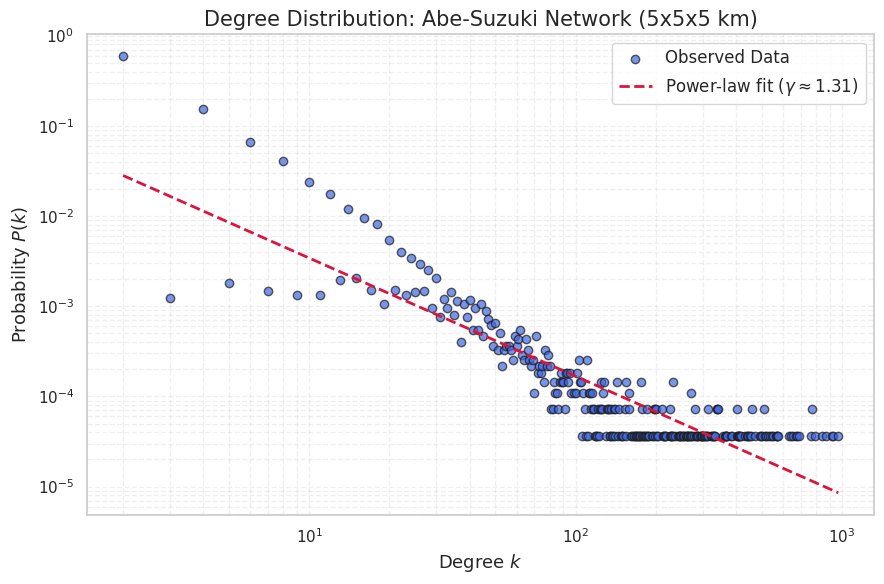

[Abe-Suzuki Network (5x5x5 km)] Power-law exponent gamma: 1.310 (R-squared: 0.788)

Analyzing 10km Resolution Network...


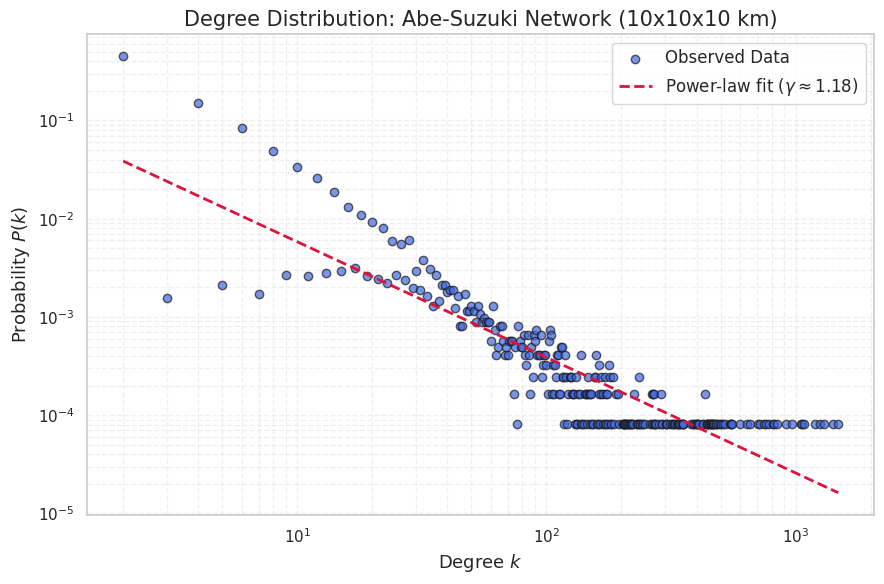

[Abe-Suzuki Network (10x10x10 km)] Power-law exponent gamma: 1.176 (R-squared: 0.787)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
import seaborn as sns

sns.set_theme(style="whitegrid")

# ==========================================
# 1. Degree Distribution Analysis Function
# ==========================================
def analyze_degree_distribution(G, title):
    """
    Extracts the degree of each node, calculates the probability distribution P(k),
    and fits a power-law to verify the scale-free property.
    """
    # 1. Extract total degree for all active nodes (in-degree + out-degree)
    # We ignore isolated nodes (degree 0) if any somehow exist
    degrees = [d for n, d in G.degree() if d > 0]
    
    # 2. Calculate frequencies and probabilities
    degree_counts = pd.Series(degrees).value_counts().sort_index()
    k = degree_counts.index.values
    P_k = degree_counts.values / len(degrees)
    
    # 3. Log-Log Linear Regression (Power-Law Fit)
    # We typically fit the tail, avoiding k=1 which can sometimes deviate 
    # due to finite size effects or catalog incompleteness.
    valid_idx = k >= 2
    log_k = np.log10(k[valid_idx])
    log_P = np.log10(P_k[valid_idx])
    
    slope, intercept, r_value, _, _ = linregress(log_k, log_P)
    
    # In a log-log plot of a power law, the slope is -gamma
    gamma = -slope
    
    # 4. Visualization
    plt.figure(figsize=(9, 6))
    
    # Scatter plot of actual data
    plt.scatter(k, P_k, color='royalblue', alpha=0.7, edgecolors='k', label='Observed Data')
    
    # Plot the fitted line
    fit_line = 10**(intercept) * (k[valid_idx]**(-gamma))
    
    # We use a raw string (fr"...") to prevent LaTeX escape issues
    plt.plot(k[valid_idx], fit_line, color='crimson', linewidth=2, linestyle='--',
             label=fr'Power-law fit ($\gamma \approx {gamma:.2f}$)')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Degree Distribution: {title}', fontsize=15)
    plt.xlabel('Degree $k$', fontsize=13)
    plt.ylabel('Probability $P(k)$', fontsize=13)
    plt.legend(fontsize=12)
    
    # Add minor grid lines for better readability on log scales
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"[{title}] Power-law exponent gamma: {gamma:.3f} (R-squared: {r_value**2:.3f})")
    
# ==========================================
# 2. Execution Pipeline
# ==========================================
# Note: This assumes G_5km and G_10km are already generated and in memory 
# from your previous execution cell.

print("Analyzing 5km Resolution Network...")
analyze_degree_distribution(G_5km, "Abe-Suzuki Network (5x5x5 km)")

print("\nAnalyzing 10km Resolution Network...")
analyze_degree_distribution(G_10km, "Abe-Suzuki Network (10x10x10 km)")

#### degree distribution with LOG-BINNING

Analyzing 5km Resolution Network with Log-Binning...


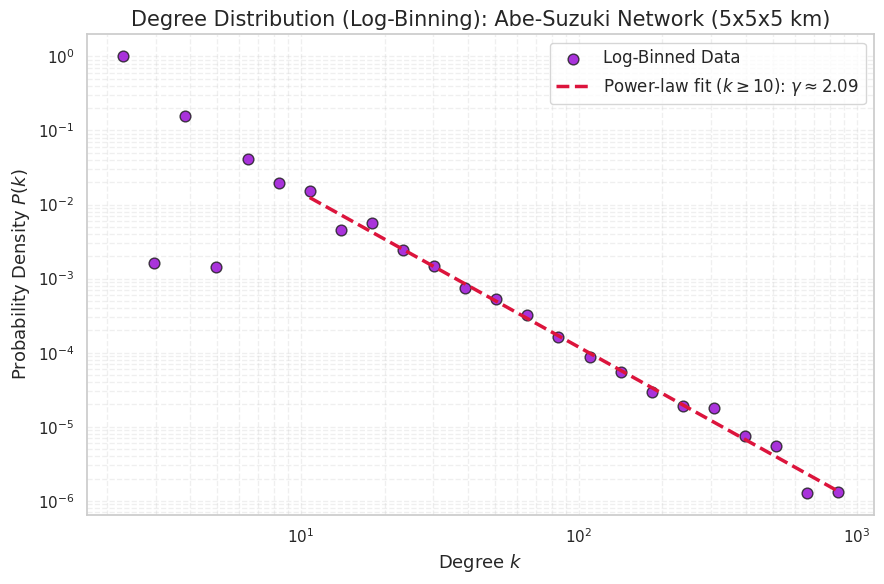

[Abe-Suzuki Network (5x5x5 km)] Power-law exponent gamma: 2.085 (R-squared: 0.992)

Analyzing 10km Resolution Network with Log-Binning...


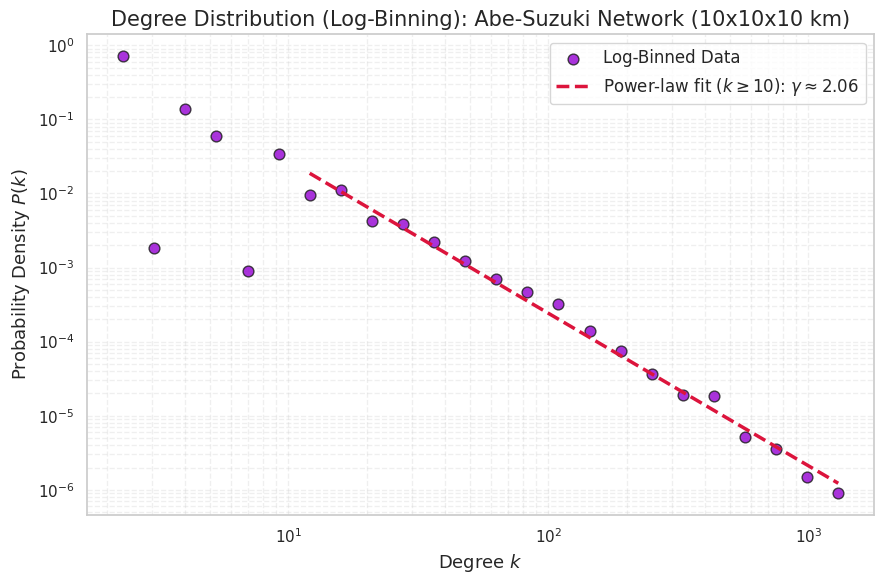

[Abe-Suzuki Network (10x10x10 km)] Power-law exponent gamma: 2.058 (R-squared: 0.990)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import seaborn as sns

sns.set_theme(style="whitegrid")

# ==========================================
# Advanced Degree Distribution (Log-Binning)
# ==========================================
def analyze_degree_distribution_log_binning(G, title, k_min_fit=10):
    """
    Analyzes the degree distribution using Logarithmic Binning, 
    which is the standard scientific approach for scale-free networks 
    to handle the heavy-tail noise.
    """
    # 1. Extract degrees (>0)
    degrees = [d for n, d in G.degree() if d > 0]
    
    if not degrees:
        print("Graph has no edges.")
        return
        
    k_min = min(degrees)
    k_max = max(degrees)
    
    # 2. Create Logarithmic Bins
    # We create bins that grow exponentially in size (e.g., 2^0, 2^1, 2^2...)
    num_bins = 25
    bins = np.logspace(np.log10(k_min), np.log10(k_max), num_bins)
    
    # 3. Calculate Histogram
    counts, bin_edges = np.histogram(degrees, bins=bins)
    
    # Calculate bin centers and bin widths
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = np.diff(bin_edges)
    
    # 4. Normalize to Probability Density P(k)
    # We must divide by the width of the bin, otherwise large bins will artificially 
    # have higher probabilities.
    P_k = counts / (len(degrees) * bin_widths)
    
    # Filter out empty bins
    valid_mask = P_k > 0
    k_valid = bin_centers[valid_mask]
    P_k_valid = P_k[valid_mask]
    
    # 5. Fit the Power-Law only on the valid structural tail (k >= k_min_fit)
    fit_mask = k_valid >= k_min_fit
    
    if sum(fit_mask) > 2: # Ensure we have enough points to fit
        log_k = np.log10(k_valid[fit_mask])
        log_P = np.log10(P_k_valid[fit_mask])
        
        slope, intercept, r_value, _, _ = linregress(log_k, log_P)
        gamma = -slope
        
        # Generate points for the fit line
        fit_line = 10**(intercept) * (k_valid[fit_mask]**(-gamma))
    else:
        gamma, r_value, fit_line = 0, 0, []

    # 6. Plotting
    plt.figure(figsize=(9, 6))
    
    # Plot log-binned data
    plt.scatter(k_valid, P_k_valid, color='darkviolet', alpha=0.8, 
                edgecolors='k', s=60, label='Log-Binned Data')
    
    # Plot the fit line
    if sum(fit_mask) > 2:
        plt.plot(k_valid[fit_mask], fit_line, color='crimson', linewidth=2.5, 
                 linestyle='--', label=fr'Power-law fit ($k \geq {k_min_fit}$): $\gamma \approx {gamma:.2f}$')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Degree Distribution (Log-Binning): {title}', fontsize=15)
    plt.xlabel('Degree $k$', fontsize=13)
    plt.ylabel('Probability Density $P(k)$', fontsize=13)
    plt.legend(fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"[{title}] Power-law exponent gamma: {gamma:.3f} (R-squared: {r_value**2:.3f})")

# ==========================================
# 3. Execution 
# ==========================================
print("Analyzing 5km Resolution Network with Log-Binning...")
# We start fitting from degree 10 to avoid initial Poissonian noise
analyze_degree_distribution_log_binning(G_5km, "Abe-Suzuki Network (5x5x5 km)", k_min_fit=10)

print("\nAnalyzing 10km Resolution Network with Log-Binning...")
analyze_degree_distribution_log_binning(G_10km, "Abe-Suzuki Network (10x10x10 km)", k_min_fit=10)

## Mapping the top 2% Hubs

In [5]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import networkx as nx

pio.renderers.default = 'iframe' 

# 1. Extract degrees and coordinates from the 10km Network
print("Extracting node metrics...")
node_data = []
for node in G_10km.nodes():
    # Only keep nodes that have coordinates (which we saved during graph building)
    if 'lat' in G_10km.nodes[node] and 'lon' in G_10km.nodes[node]:
        node_data.append({
            'cell_id': node,
            'degree': G_10km.degree(node),
            'lat': G_10km.nodes[node]['lat'],
            'lon': G_10km.nodes[node]['lon']
        })

df_nodes = pd.DataFrame(node_data)

# 2. Filter out isolated cells to clean up the map
df_nodes = df_nodes[df_nodes['degree'] > 0]

# 3. Identify the "Hubs" (e.g., the top 2% most active cells)
threshold = df_nodes['degree'].quantile(0.98)
df_hubs = df_nodes[df_nodes['degree'] >= threshold].copy()

print(f"Total active cells: {len(df_nodes)}")
print(f"Mapping the top {len(df_hubs)} Hubs (Degree >= {threshold:.0f})...")

# 4. Plot the Hubs interactively
fig = px.scatter_mapbox(
    df_hubs, 
    lat="lat", 
    lon="lon", 
    color="degree",
    size="degree",
    color_continuous_scale="inferno", # Great colormap for heat/intensity
    zoom=4.5,
    center={"lat": 41.9, "lon": 12.5},
    mapbox_style="carto-darkmatter", # Dark background makes the bright hubs pop
    hover_name="cell_id",
    hover_data={"lat": ":.3f", "lon": ":.3f", "degree": True},
    title="Abe-Suzuki Network Hubs: Top 2% Most Active Seismic Cells (10x10x10 km)"
)

fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

Extracting node metrics...
Total active cells: 12265
Mapping the top 250 Hubs (Degree >= 115)...


/tmp/ipykernel_131563/899118188.py:34: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## Generating upgraded 3D Network Hub Map with Italy surface map

In [6]:
import plotly.graph_objects as go
import plotly.express as px
import geopandas as gpd
import pandas as pd

print("Fetching Italy's geometry to draw the surface map...")

# 1. Fetch Italy Boundaries (We use the same URL as before)
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
italy_geom = world[world['ADMIN'] == "Italy"].geometry.iloc[0]

# Safely handle both standard Polygons and MultiPolygons (like Italy + Sicily + Sardinia)
geometries = [italy_geom] if italy_geom.geom_type == 'Polygon' else italy_geom.geoms
df_hubs['depth_km'] = df_hubs['cell_id'].apply(lambda x: float(x.split('_')[2]) * 10)
# Extract coordinates to draw the lines
lons_map, lats_map, zs_map = [], [], []
for polygon in geometries:
    x, y = polygon.exterior.coords.xy
    lons_map.extend(x)
    lats_map.extend(y)
    zs_map.extend([0] * len(x)) # Place the map exactly at surface level (Depth = 0)
    
    # Add None to break the line so Plotly doesn't draw a line connecting Sicily to Milan!
    lons_map.append(None)
    lats_map.append(None)
    zs_map.append(None)

print("Generating upgraded 3D Network Hub Map...")

# 2. Re-create the base 3D Scatter for the Hubs
fig_3d = px.scatter_3d(
    df_hubs, 
    x='lon', y='lat', z='depth_km',
    color='degree', size='degree',
    color_continuous_scale='inferno',
    hover_name='cell_id',
    hover_data={'lat': ':.2f', 'lon': ':.2f', 'depth_km': True, 'degree': True}
)

# 3. Add the map outline trace to the figure
fig_3d.add_trace(go.Scatter3d(
    x=lons_map, y=lats_map, z=zs_map,
    mode='lines',
    line=dict(color='cyan', width=3), # Bright cyan wireframe for the coast
    name='Italy Surface (0 km)',
    hoverinfo='skip'
))

# 4. Apply a dark theme and configure the axes
fig_3d.update_layout(
    template="plotly_dark", # Dark mode makes the hubs and glowing map pop
    scene=dict(
        zaxis=dict(autorange="reversed", title="Depth (km)"),
        xaxis=dict(title="Longitude"),
        yaxis=dict(title="Latitude"),
        # Adjust aspect ratio so Italy isn't squished into a perfect cube
        aspectratio=dict(x=1, y=1.5, z=0.6) 
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    title="3D View of Seismic Hubs with Surface Coastline"
)

fig_3d.show()

Fetching Italy's geometry to draw the surface map...
Generating upgraded 3D Network Hub Map...


# Macroscopic Network Analysis

## Calculating some metrics
- Giant Component Analysis
- Clustering coefficients
- Diameter and Path average length
- Adjacency Matrix

  MACROSCOPIC SEISMIC NETWORK ANALYSIS   

--- 1. Giant Component Analysis ---
Total isolated components: 1
Giant Component Size: 12265 nodes (100.00% of the whole network)
Physical Meaning: 100.00% of active Italian seismic cells are structurally linked together.

--- 2. Clustering Coefficient ---
Average Clustering Coefficient (C): 0.1839
Expected C for a Random Graph:    0.0011
Physical Meaning: A C value much higher than the random expectation proves intense local aftershock clustering.

--- 3. Diameter & Average Path Length ---
Calculating shortest paths... (takes a bit...)
Average Path Length (L): 3.20 steps
Network Diameter:        7 steps
Calculation time:        629.7 seconds
Physical Meaning: On average, any seismic cell is only 3.20 'jumps' away from any other cell in Italy.

--- 4. Adjacency Matrix ---
Matrix Shape: (12265, 12265)
Non-Zero elements (Edges): 92340
Matrix Sparsity: 99.9386%


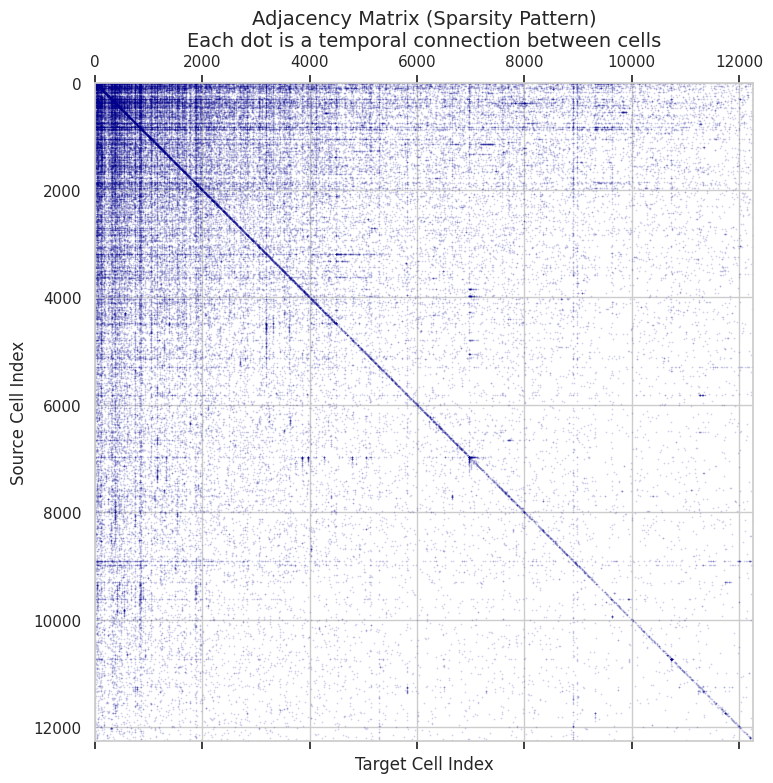

In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time
import scipy.sparse as sp

# Assuming G_10km is loaded from the previous steps
G = G_10km

print("=========================================")
print("  MACROSCOPIC SEISMIC NETWORK ANALYSIS   ")
print("=========================================\n")

# ---------------------------------------------------------
# 1. Connectivity & Giant Component
# ---------------------------------------------------------
print("--- 1. Giant Component Analysis ---")
# In directed graphs, we use Weakly Connected Components (ignoring time direction)
# to find the overall physical structure.
wcc = list(nx.weakly_connected_components(G))
largest_wcc_nodes = max(wcc, key=len)
G_giant = G.subgraph(largest_wcc_nodes).copy()

total_nodes = G.number_of_nodes()
giant_nodes = G_giant.number_of_nodes()
percentage = (giant_nodes / total_nodes) * 100

print(f"Total isolated components: {len(wcc)}")
print(f"Giant Component Size: {giant_nodes} nodes ({percentage:.2f}% of the whole network)")
print(f"Physical Meaning: {percentage:.2f}% of active Italian seismic cells are structurally linked together.\n")

# ---------------------------------------------------------
# 2. Clustering Coefficient (Triangles)
# ---------------------------------------------------------
print("--- 2. Clustering Coefficient ---")
# To analyze physical triangles (A-B-C-A), we often convert to undirected
# to avoid directional strictness (A must cause B, B must cause C).
G_undirected = G_giant.to_undirected()

# Remove self-loops for clustering calculation (NetworkX requirement)
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

start_time = time.time()
avg_clustering = nx.average_clustering(G_undirected)
print(f"Average Clustering Coefficient (C): {avg_clustering:.4f}")

# Calculate the clustering of a random graph with the same N and E for comparison
p_random = (2 * G_undirected.number_of_edges()) / (giant_nodes * (giant_nodes - 1))
print(f"Expected C for a Random Graph:    {p_random:.4f}")
print("Physical Meaning: A C value much higher than the random expectation proves intense local aftershock clustering.\n")

# ---------------------------------------------------------
# 3. Path Length and Diameter
# ---------------------------------------------------------
print("--- 3. Diameter & Average Path Length ---")
print("Calculating shortest paths... (takes a bit...)")

start_time = time.time()
# We compute this on the Undirected Giant Component. 
# (In a DiGraph, if there is no path back in time, the distance is infinite).
avg_path_length = nx.average_shortest_path_length(G_undirected)
diameter = nx.diameter(G_undirected)
calc_time = time.time() - start_time

print(f"Average Path Length (L): {avg_path_length:.2f} steps")
print(f"Network Diameter:        {diameter} steps")
print(f"Calculation time:        {calc_time:.1f} seconds")
print(f"Physical Meaning: On average, any seismic cell is only {avg_path_length:.2f} 'jumps' away from any other cell in Italy.\n")

# ---------------------------------------------------------
# 4. Adjacency Matrix & Sparsity
# ---------------------------------------------------------
print("--- 4. Adjacency Matrix ---")
# Extract as a SciPy sparse matrix for memory efficiency
adj_matrix = nx.to_scipy_sparse_array(G)
sparsity = 1.0 - (adj_matrix.nnz / (total_nodes ** 2))

print(f"Matrix Shape: {adj_matrix.shape}")
print(f"Non-Zero elements (Edges): {adj_matrix.nnz}")
print(f"Matrix Sparsity: {sparsity * 100:.4f}%")

# Plotting the Adjacency Matrix
plt.figure(figsize=(8, 8))
plt.spy(adj_matrix, markersize=0.05, color='darkblue')
plt.title("Adjacency Matrix (Sparsity Pattern)\nEach dot is a temporal connection between cells", fontsize=14)
plt.xlabel("Target Cell Index", fontsize=12)
plt.ylabel("Source Cell Index", fontsize=12)
plt.tight_layout()
plt.show()

## CALCULATING GLOBAL CENTRALITY METRICS  
- Degree Centrality
- PageRank
- Closeness Centrality
- Betweenness Centrality (K=1000)


In [8]:
import pandas as pd
import networkx as nx
import time

print("=========================================")
print("  CALCULATING GLOBAL CENTRALITY METRICS  ")
print("=========================================\n")

start_time = time.time()

# 1. Degree Centrality (Normalized degree)
print("1/4 Computing Degree Centrality...")
deg_cent = nx.degree_centrality(G_10km)

# 2. PageRank Centrality
# We use weight='weight' because Abe-Suzuki counts multiple transitions 
# between the same cells, which strongly influences stress flow.
print("2/4 Computing PageRank Centrality...")
pagerank_cent = nx.pagerank(G_10km, weight='weight')

# 3. Closeness Centrality
print("3/4 Computing Closeness Centrality (This might take a bit)...")
# Note: In a directed graph, nx.closeness_centrality calculates *inward* closeness 
# (how easily stress reaches this node). If you want *outward* (how easily this node 
# spreads stress), you would use G_10km.reverse(). We will use the standard inward here.
close_cent = nx.closeness_centrality(G_10km)

# 4. Betweenness Centrality (Recalculating quickly for the consolidated table)
print("4/4 Computing Betweenness Centrality (Sampled k=1000)...")
bet_cent = nx.betweenness_centrality(G_10km, k=1000, seed=42)

calc_time = time.time() - start_time
print(f"\nAll metrics calculated in {calc_time:.1f} seconds!")

# ==========================================
# Build the Master DataFrame
# ==========================================
metrics_data = []
for node in G_10km.nodes():
    if 'lat' in G_10km.nodes[node] and 'lon' in G_10km.nodes[node]:
        metrics_data.append({
            'cell_id': node,
            'lat': G_10km.nodes[node]['lat'],
            'lon': G_10km.nodes[node]['lon'],
            'depth_km': float(node.split('_')[2]) * 10,  # Recover depth from ID
            'Degree': deg_cent[node],
            'Betweenness': bet_cent[node],
            'Closeness': close_cent[node],
            'PageRank': pagerank_cent[node]
        })

df_centrality = pd.DataFrame(metrics_data)

# ==========================================
# Display the Top 5 Cells for Each Metric
# ==========================================
def display_top_5(df, metric, title):
    print(f"\n--- Top 5 Cells: {title} ---")
    top_5 = df.sort_values(metric, ascending=False).head(5)
    # Format the output for clean reading
    display(top_5[['cell_id', 'lat', 'lon', 'depth_km', metric]].style.format({
        'lat': "{:.3f}", 'lon': "{:.3f}", 'depth_km': "{:.1f}", metric: "{:.6f}"
    }))

display_top_5(df_centrality, 'Degree', 'Most Active Swarms (Degree)')
display_top_5(df_centrality, 'Betweenness', 'Structural Bridges (Betweenness)')
display_top_5(df_centrality, 'Closeness', 'Topological Centers (Closeness)')
display_top_5(df_centrality, 'PageRank', 'Stress Sinks (PageRank)')

  CALCULATING GLOBAL CENTRALITY METRICS  

1/4 Computing Degree Centrality...
2/4 Computing PageRank Centrality...
3/4 Computing Closeness Centrality (This might take a bit)...
4/4 Computing Betweenness Centrality (Sampled k=1000)...

All metrics calculated in 217.1 seconds!

--- Top 5 Cells: Most Active Swarms (Degree) ---


,cell_id,lat,lon,depth_km,Degree
106,79_90_1,42.554,13.248,10.0,0.120841
33,78_93_1,42.809,13.133,10.0,0.114644
866,79_91_1,42.633,13.241,10.0,0.106246
381,73_99_0,43.380,12.529,0.0,0.102087
834,79_92_1,42.726,13.231,10.0,0.097521



--- Top 5 Cells: Structural Bridges (Betweenness) ---


,cell_id,lat,lon,depth_km,Betweenness
106,79_90_1,42.554,13.248,10.0,0.063552
866,79_91_1,42.633,13.241,10.0,0.054436
33,78_93_1,42.809,13.133,10.0,0.054082
381,73_99_0,43.380,12.529,0.0,0.051117
834,79_92_1,42.726,13.231,10.0,0.047407



--- Top 5 Cells: Topological Centers (Closeness) ---


,cell_id,lat,lon,depth_km,Closeness
106,79_90_1,42.554,13.248,10.0,0.434093
33,78_93_1,42.809,13.133,10.0,0.427988
866,79_91_1,42.633,13.241,10.0,0.427705
834,79_92_1,42.726,13.231,10.0,0.424683
1047,80_89_1,42.460,13.340,10.0,0.422532



--- Top 5 Cells: Stress Sinks (PageRank) ---


,cell_id,lat,lon,depth_km,PageRank
33,78_93_1,42.809,13.133,10.0,0.020436
834,79_92_1,42.726,13.231,10.0,0.014892
106,79_90_1,42.554,13.248,10.0,0.014397
415,77_95_0,43.010,13.045,0.0,0.013993
866,79_91_1,42.633,13.241,10.0,0.013380


## Community Detection algorithm

### Louvain Algorithm

In [9]:
import networkx as nx
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import geopandas as gpd

print("=========================================")
print("  COMMUNITY DETECTION (LOUVAIN METHOD)   ")
print("=========================================\n")

# 1. Prepare the network for Louvain
# Louvain works best on Undirected graphs. We will use the Giant Component.
G_undirected = G_giant.to_undirected()

# Remove self-loops as they don't contribute to inter-community connections
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

print("Running Louvain algorithm...")
# 2. Run the algorithm
# nx.community.louvain_communities returns a list of sets, where each set is a community of nodes
communities = nx.community.louvain_communities(G_undirected, seed=42)

print(f"Algorithm discovered {len(communities)} distinct seismic communities.\n")

# 3. Assign community IDs to the nodes
community_mapping = {}
for comm_id, node_set in enumerate(communities):
    for node in node_set:
        community_mapping[node] = comm_id

# 4. Extract data for visualization
comm_data = []
for node in G_undirected.nodes():
    if 'lat' in G_undirected.nodes[node] and 'lon' in G_undirected.nodes[node]:
        comm_data.append({
            'cell_id': node,
            'community': str(community_mapping[node]), # Convert to string for discrete colors in Plotly
            'lat': G_undirected.nodes[node]['lat'],
            'lon': G_undirected.nodes[node]['lon'],
            'degree': G_undirected.degree(node)
        })

df_comm = pd.DataFrame(comm_data)

# Filter out tiny communities (noise) to make the map readable
# Let's keep only communities that have at least 50 cells
comm_counts = df_comm['community'].value_counts()
large_communities = comm_counts[comm_counts >= 50].index
df_comm_filtered = df_comm[df_comm['community'].isin(large_communities)].copy()

print(f"Mapping the {len(large_communities)} largest structural fault systems...")

# 5. Fetch Italy boundaries for the surface map
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
italy_geom = world[world['ADMIN'] == "Italy"].geometry.iloc[0]
geometries = [italy_geom] if italy_geom.geom_type == 'Polygon' else italy_geom.geoms

lons_map, lats_map = [], []
for polygon in geometries:
    x, y = polygon.exterior.coords.xy
    lons_map.extend(x)
    lats_map.extend(y)
    lons_map.append(None)
    lats_map.append(None)

# 6. Plot the Communities
fig_comm = px.scatter_mapbox(
    df_comm_filtered, 
    lat="lat", 
    lon="lon", 
    color="community", # Color by community ID
    size="degree",     # Size by degree to see the hubs within each community
    color_discrete_sequence=px.colors.qualitative.Bold, # Distinct colors for categories
    zoom=4.5,
    center={"lat": 41.9, "lon": 12.5},
    mapbox_style="carto-darkmatter",
    hover_name="community",
    hover_data={"lat": ":.3f", "lon": ":.3f", "degree": True},
    title="Seismic Communities (Louvain Method): Distinct Fault Systems"
)

fig_comm.add_trace(go.Scattermapbox(
    lat=lats_map,
    lon=lons_map,
    mode='lines',
    line=dict(color='white', width=0.5),
    hoverinfo='skip',
    name='Coastline'
))

fig_comm.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0}, showlegend=False)
fig_comm.show()

  COMMUNITY DETECTION (LOUVAIN METHOD)   

Running Louvain algorithm...
Algorithm discovered 14 distinct seismic communities.

Mapping the 14 largest structural fault systems...


/tmp/ipykernel_131563/3222013323.py:68: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_comm = px.scatter_mapbox(
/tmp/ipykernel_131563/3222013323.py:83: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_comm.add_trace(go.Scattermapbox(


## SAVE Centrality Results
- CellID
- Degree
- Betweenness
- Closeness
- PageRank


In [10]:
# Merge the centrality data with the community data
df_final_results = pd.merge(df_centrality, df_comm[['cell_id', 'community']], on='cell_id', how='left')

# Save to CSV for your final report
df_final_results.to_csv("results/italian_seismic_network_metrics.csv", index=False)
print("Project data successfully exported to 'italian_seismic_network_metrics.csv'!")

Project data successfully exported to 'italian_seismic_network_metrics.csv'!
